# WESM Price Prediction - Model 1: Linear Regression

## Setup and Loading

This notebook implements a Vanilla Linear Regression model as the baseline for predicting Luzon GWAP (Generation Weighted Average Price) from WESM market features.

Vanilla Linear Regression is chosen as the first model as it serves as a **baseline** for comparing more complex models.

The model is evaluated using RMSE, MAE, and R², with a chronological train/validation/test split to avoid data leakage.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(df.head())

Dataset Shape: (34535, 19)
Date Range: 2025-10-29 00:05:00 to 2026-02-26 00:00:00
             datetime       GWAP  energy_demand_mw  energy_supply_mw  \
0 2025-10-29 00:05:00  2258.5866           9504.45           9705.25   
1 2025-10-29 00:10:00  2913.4257           9483.49           9648.89   
2 2025-10-29 00:15:00  2883.5764           9434.35           9627.98   
3 2025-10-29 00:20:00  2888.6233           9417.62           9614.19   
4 2025-10-29 00:25:00  2887.9553           9379.48           9575.17   

   energy_shortage_mw  reserve_demand_mw  reserve_supply_mw  outage_count  \
0             -200.80             1428.0             1428.0           4.0   
1             -165.40             1428.0             1428.0           4.0   
2             -193.63             1428.0             1428.0           4.0   
3             -196.57             1428.0             1428.0           4.0   
4             -195.69             1428.0             1428.0           4.0   

   GWAP_Lag_1  GWAP_La

---

## I. Feature Selection

The target variable is `GWAP`. The following features are used as inputs:

| Feature | Justification |
|---|---|
| `energy_demand_mw` | Higher demand drives up price |
| `energy_supply_mw` | Higher supply suppresses price |
| `reserve_demand_mw` | Reserve requirements affect market tightness |
| `reserve_supply_mw` | Reserve availability affects market stability |
| `outage_count` | More outages reduce available capacity, pushing price up |
| `GWAP_Lag_1` | Strong autoregressive signal (price 5 minutes ago) |
| `GWAP_Lag_12` | Intra-hour price memory (1 hour ago) |
| `GWAP_Lag_288` | Same-time-yesterday seasonality (24 hours ago) |
| `hour_sin`, `hour_cos` | Cyclical encoding of intraday price patterns |
| `dow_1` to `dow_6` | Day-of-week effects (weekday vs. weekend demand) |

**Note:** `energy_shortage_mw` is excluded because it is a linear combination of `energy_demand_mw` and `energy_supply_mw` (`shortage = demand - supply`). Including all three would introduce perfect multicollinearity, making linear regression coefficients unreliable. It is retained in the dataset for EDA purposes only.

`datetime` is retained in the dataframe for split indexing and visualization, but is **not** passed into the model as a feature.

In [37]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of features: 16
Features: ['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


---

## II. Train / Validation / Test Split

Because this is a time-series dataset, a **chronological split** is used instead of a random split. Random splitting would cause data leakage: the lag features (`GWAP_Lag_1`, `GWAP_Lag_12`, `GWAP_Lag_288`) reference past GWAP values, so if future rows appear in training, the model would effectively "see the future" during training.

The dataset spans approximately 4 months (late October 2025 to late February 2026). The split is:
- **Train**: first 70% of rows (~Oct 29 – Jan 20)
- **Validation**: next 10% of rows (~Jan 20 – Feb 1)
- **Test**: final 20% of rows (~Feb 1 – Feb 26)

**Note:** Since Vanilla Linear Regression has no hyperparameters to tune, the validation set is not used for model selection in this notebook. It is evaluated here solely to maintain a consistent evaluation framework with subsequent models, where the validation set will be used to determine hyperparameters.

In [38]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  24174 rows | 2025-10-29 to 2026-01-20
Val   :   3454 rows | 2026-01-20 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


The plot below shows the chronological split. Each color represents a different split, making it clear that no future data is included in the training period.

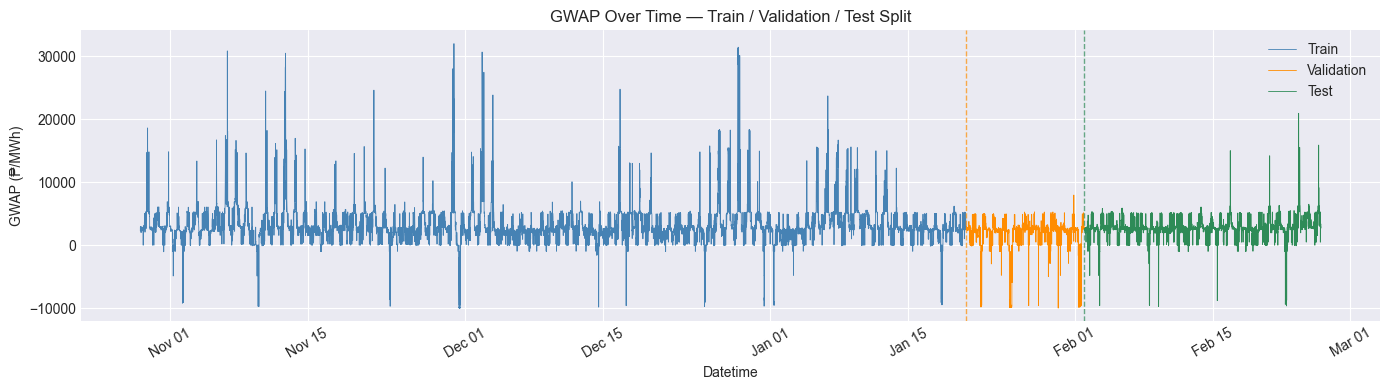

In [39]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_df["datetime"], train_df["GWAP"], color="steelblue",  label="Train",      linewidth=0.6)
ax.plot(val_df["datetime"],   val_df["GWAP"],   color="darkorange", label="Validation", linewidth=0.6)
ax.plot(test_df["datetime"],  test_df["GWAP"],  color="seagreen",   label="Test",       linewidth=0.6)

ax.axvline(train_df["datetime"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(val_df["datetime"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("GWAP Over Time — Train / Validation / Test Split")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [40]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

---

## III. Feature Scaling

**Standardization** (zero mean, unit variance) is applied to all features. This is important for two reasons:

1. Features are on very different scales ( `energy_demand_mw` is in the thousands of MW, while `hour_sin`/`hour_cos` are between -1 and 1). Without scaling, features with larger magnitudes would dominate the coefficient values, making them hard to interpret and compare.
2. Standardization is required for fair comparison when we later apply regularized models (Ridge, Elastic Net), where the penalty is applied equally across all coefficients.

The scaler is **fit only on the training set**. The validation and test sets are then transformed using the training set's mean and standard deviation to avoid data leakage.

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Transform val and test using training statistics
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train mean: {X_train_scaled.mean(axis=0).mean():.6f}")
print(f"Train std: {X_train_scaled.std(axis=0).mean():.6f}")

Train mean: -0.000000
Train std: 1.000000


---

## IV. Model Training

Two models are trained:

1. **`lr`** — trained on the training set only. This is the model used to evaluate train and validation performance, and would be used for hyperparameter selection in regularized models.
2. **`lr_final`** — retrained on the combined train + validation set. Since no hyperparameters needed to be selected, `lr_final` is identical in configuration to `lr` but has seen more data. This is the model used for final test evaluation, following standard protocol: once the selection phase is complete, all non-test data should be used for the final fit.

Both use the ordinary least squares (OLS) analytical solution.

In [42]:
# Model for train/val evaluation (selection phase)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Final model retrained on train + val combined (for test evaluation)
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval        = pd.concat([y_train, y_val])

lr_final = LinearRegression()
lr_final.fit(X_trainval_scaled, y_trainval)

print(f"lr       intercept (train only)  : {lr.intercept_:.4f}")
print(f"lr_final intercept (train + val) : {lr_final.intercept_:.4f}")

lr       intercept (train only)  : 3211.3488
lr_final intercept (train + val) : 3211.8770


---

## V. Evaluation

The model is evaluated across all three splits using:
- **RMSE** (Root Mean Squared Error): primary metric; same unit as GWAP (₱/MWh), penalizes large errors more heavily.
- **MAE** (Mean Absolute Error): average absolute error; less sensitive to extreme price spikes.
- **R²** (Coefficient of Determination): proportion of GWAP variance explained by the model. R² = 1 is perfect; R² = 0 means the model is no better than predicting the mean.

Train and validation are evaluated using `lr` (trained on train only). The test set is evaluated using `lr_final` (trained on train + val), following the standard protocol of using all available non-test data for the final model.

In [53]:
def evaluate(model, X, y, label):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)
    print(f"{label:<12} | RMSE: {rmse:>10.4f} | MAE: {mae:>10.4f} | R\u00b2: {r2:>8.4f}")
    return y_pred, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>14} | {'MAE':>14} | {'R\u00b2':>12}")
print("-" * 58)
# lr evaluated on its own training data
y_train_pred, train_rmse, train_mae, train_r2 = evaluate(lr, X_train_scaled, y_train, "Train")

# lr evaluated on validation (unseen to lr)  
y_val_pred, val_rmse, val_mae, val_r2 = evaluate(lr, X_val_scaled, y_val, "Validation")

# lr_final evaluated on its own training data (train+val combined)
y_trainval_pred, trainval_rmse, _, _ = evaluate(lr_final, X_trainval_scaled, y_trainval, "Train+Val")

# lr_final evaluated on test (unseen to lr_final)
y_test_pred, test_rmse, test_mae, test_r2 = evaluate(lr_final, X_test_scaled, y_test, "Test")

Split        |           RMSE |            MAE |           R²
----------------------------------------------------------
Train        | RMSE:  1212.1420 | MAE:   567.8438 | R²:   0.8137
Validation   | RMSE:  1066.3745 | MAE:   521.5860 | R²:   0.8321
Train+Val    | RMSE:  1194.6325 | MAE:   560.4642 | R²:   0.8219
Test         | RMSE:   934.4698 | MAE:   459.4758 | R²:   0.6714


### Bias-Variance Diagnosis

Following the diagnostic framework from the Tips and Tricks lecture, each model is compared
against its own training performance as the reference baseline:

- **`lr`** (trained on train only): compared against its train RMSE for the val gap.
- **`lr_final`** (trained on train+val): compared against its train+val RMSE for the test gap.

This ensures an apples-to-apples comparison — each gap measures how much worse the model
does on data it has never seen, relative to data it was actually fit on.

- A **large positive gap** indicates overfitting (high variance) — the model memorized its
  training data and failed to generalize.
- A **negative gap** means that split was easier to predict than the training period, not
  that something went wrong.
- If **the training RMSE itself is high**, the model is underfitting (high bias) regardless
  of how the other splits compare.

**Val − Train (`lr`):** Validation RMSE (1,066) is slightly *lower* than train RMSE (1,212),
a gap of roughly −12%. The January validation period simply contained less volatile GWAP
intervals than the October–January training period. No overfitting.

**Test − Train+Val (`lr_final`):** Test RMSE (934) is lower than train+val RMSE (1,195) in
absolute terms, a gap of roughly −21%. Again, this reflects that February's typical intervals
were easier to predict than the combined training window on average. However, the test R²
drops noticeably from validation (0.832 → 0.671), which tells a more nuanced story — February
contained more extreme price spikes that disproportionately inflate error variance even when
median errors remain low. RMSE and R² can tell different stories when the error distribution
has heavy tails, as is the case here.

In [54]:
gap_val  = val_rmse - train_rmse        # lr on unseen val vs lr on train
gap_test = test_rmse - trainval_rmse    # lr_final on unseen test vs lr_final on train+val

print(f"Train RMSE      : {train_rmse:.4f}  (lr, selection phase)")
print(f"Validation RMSE : {val_rmse:.4f}  (lr, unseen)")
print(f"Train+Val RMSE  : {trainval_rmse:.4f}  (lr_final, what it trained on)")
print(f"Test RMSE       : {test_rmse:.4f}  (lr_final, unseen)")
print()
print(f"Val  - Train gap     : {gap_val:.4f}  ({gap_val / train_rmse * 100:.1f}% of train RMSE)")
print(f"Test - Train+Val gap : {gap_test:.4f}  ({gap_test / trainval_rmse * 100:.1f}% of train+val RMSE)")

Train RMSE      : 1212.1420  (lr, selection phase)
Validation RMSE : 1066.3745  (lr, unseen)
Train+Val RMSE  : 1194.6325  (lr_final, what it trained on)
Test RMSE       : 934.4698  (lr_final, unseen)

Val  - Train gap     : -145.7675  (-12.0% of train RMSE)
Test - Train+Val gap : -260.1627  (-21.8% of train+val RMSE)


---

## VI. Visualizations

### Actual vs. Predicted — Test Set (Time Series)

This plot overlays the model's predictions on the actual GWAP values over the test period (February 2026). The model tracks the general trend and typical price range well. However, it visibly lags or undershoots during sudden price spikes — most notably the sharp upward and downward extremes — which is an inherent limitation of a linear model applied to non-linear market dynamics.

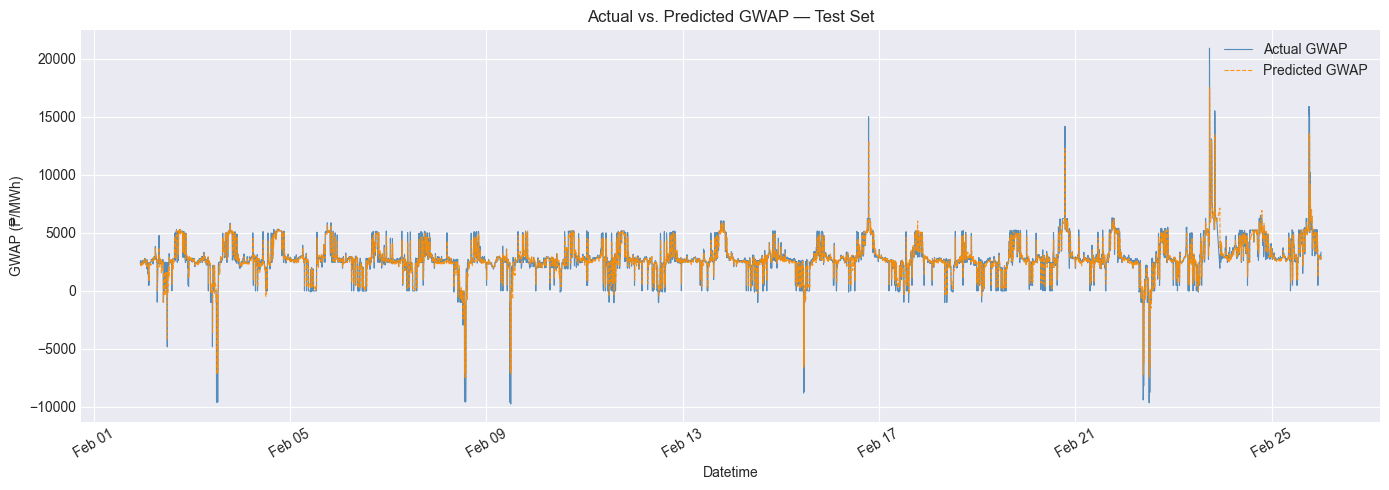

In [45]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_df["datetime"].values, y_test.values,     color="steelblue",  linewidth=0.8, label="Actual GWAP",    alpha=0.9)
ax.plot(test_df["datetime"].values, y_test_pred,       color="darkorange", linewidth=0.8, label="Predicted GWAP", alpha=0.9, linestyle="--")

ax.set_title("Actual vs. Predicted GWAP — Test Set")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Actual vs. Predicted — Scatter Plot

A scatter plot of actual vs. predicted values is shown below. Points close to the diagonal (y = x) indicate accurate predictions. The dense cluster around ₱2,000–₱5,000 sits close to the diagonal, confirming good fit in the normal price range. Deviations are most visible at the extremes: at high actual GWAP values the model underpredicts (points fall below the diagonal), and at negative GWAP values the model also struggles to reach the same depth (points fall above the diagonal).

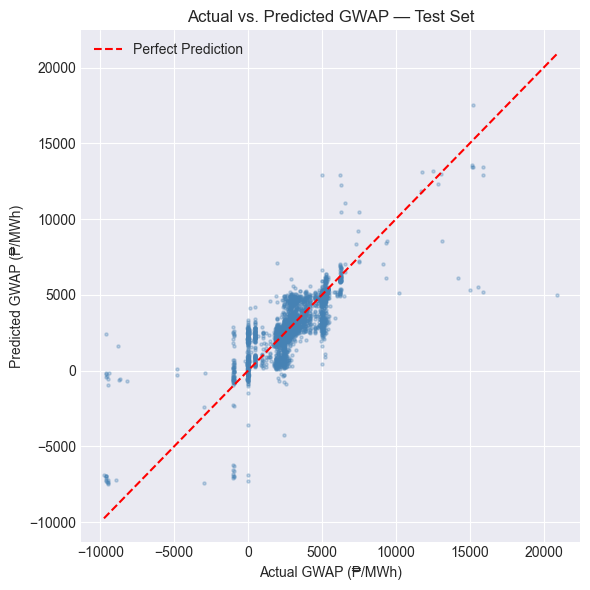

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_test_pred, alpha=0.3, s=5, color="steelblue")

# Perfect prediction line
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_title("Actual vs. Predicted GWAP — Test Set")
ax.set_xlabel("Actual GWAP (₱/MWh)")
ax.set_ylabel("Predicted GWAP (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

### Residual Plot

Residuals are the difference between actual and predicted GWAP (actual − predicted). Ideally, residuals should be randomly distributed around zero with no visible pattern.

The residual time series shows the model is generally well-centered — the mean residual is only −7.19 ₱/MWh, indicating minimal systematic bias. However, there are clear spikes in both directions throughout February, corresponding to price events the linear model could not fully capture.

The residual distribution is heavily leptokurtic (tall and narrow with fat tails): most predictions are very close to actual values, but a non-trivial number of extreme errors exist on both ends. This is consistent with electricity price data, where the bulk of intervals are well-behaved but rare spike events produce large errors regardless of model complexity.

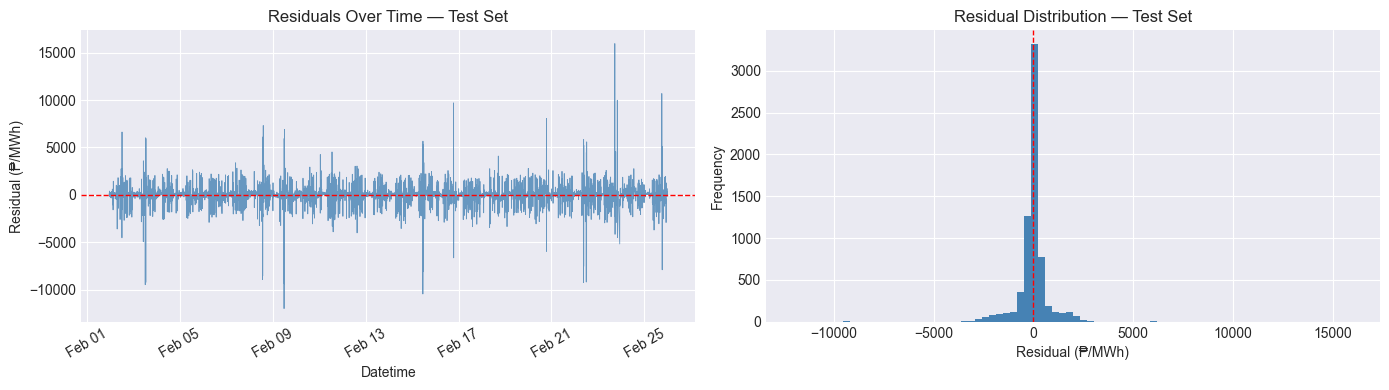

Mean Residual : -7.1931  (close to 0 = unbiased)
Std Residual  : 934.4421
Max Residual  : 15962.6729
Min Residual  : -12001.9491


In [47]:
residuals_test = y_test.values - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals over time
axes[0].plot(test_df["datetime"].values, residuals_test, color="steelblue", linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals Over Time — Test Set")
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("Residual (₱/MWh)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Residual distribution
axes[1].hist(residuals_test, bins=80, color="steelblue", edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residual Distribution — Test Set")
axes[1].set_xlabel("Residual (₱/MWh)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals_test.mean():.4f}  (close to 0 = unbiased)")
print(f"Std Residual  : {residuals_test.std():.4f}")
print(f"Max Residual  : {residuals_test.max():.4f}")
print(f"Min Residual  : {residuals_test.min():.4f}")

---

## VII. Feature Coefficients

Since all features were standardized before training, the coefficients are on the same scale and can be directly compared. A larger absolute coefficient means that feature has a stronger influence on the predicted GWAP.

Coefficients are taken from `lr_final` (the model trained on train + val) since that is the model used for test evaluation.

Note that because `energy_demand_mw`, `energy_supply_mw`, and the reserve features are moderately correlated with each other, their individual coefficients should be interpreted with caution — multicollinearity can inflate or deflate coefficients even after scaling.

In [48]:
coef_df = pd.DataFrame({
    "Feature"    : FEATURE_COLS,
    "Coefficient": lr_final.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(coef_df.to_string(index=False))

          Feature  Coefficient
       GWAP_Lag_1  2174.522593
      GWAP_Lag_12   271.347352
     GWAP_Lag_288   251.618408
 energy_demand_mw   164.249718
 energy_supply_mw  -116.163601
            dow_6   -77.448140
            dow_3   -58.967232
            dow_5   -58.056388
reserve_supply_mw    53.071628
            dow_2   -48.993079
            dow_4   -41.671495
            dow_1   -31.237746
reserve_demand_mw   -17.723856
         hour_sin   -13.335070
     outage_count     2.675542
         hour_cos    -2.544932


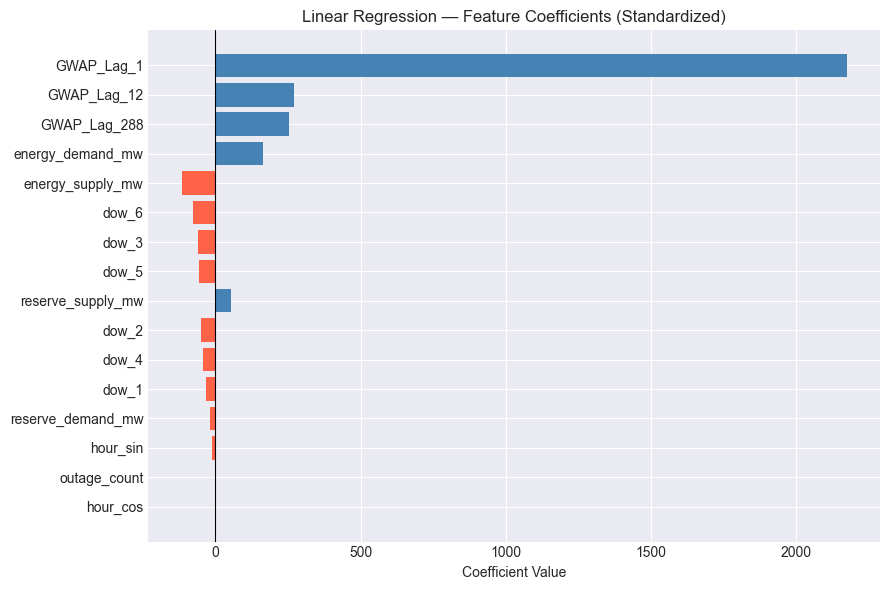

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ["steelblue" if c >= 0 else "tomato" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_title("Linear Regression — Feature Coefficients (Standardized)")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

## VIII. Error Analysis

### Where Does the Model Fail?

The residual analysis confirms that errors are not uniformly distributed — they are concentrated at the extremes. To quantify this, we segment the test set by GWAP range and compute RMSE and MAE per segment.

In [50]:
error_df = test_df[["datetime", "GWAP"]].copy()
error_df["predicted"] = y_test_pred
error_df["residual"]  = error_df["GWAP"] - error_df["predicted"]
error_df["abs_error"] = error_df["residual"].abs()

# Segment by GWAP range
bins   = [-10000, 0, 2000, 5000, 10000, 35000]
labels = ["Negative", "0–2k", "2k–5k", "5k–10k", ">10k"]
error_df["gwap_segment"] = pd.cut(error_df["GWAP"], bins=bins, labels=labels)

segment_summary = error_df.groupby("gwap_segment", observed=True).agg(
    count      = ("GWAP", "count"),
    mean_gwap  = ("GWAP", "mean"),
    rmse       = ("residual", lambda x: np.sqrt((x**2).mean())),
    mae        = ("abs_error", "mean")
).reset_index()

print(segment_summary.to_string(index=False))

gwap_segment  count    mean_gwap        rmse         mae
    Negative    459  -695.253988 2208.886686 1308.144410
        0–2k    411  1084.738367 1220.638104  914.756695
       2k–5k   5219  2806.565112  562.212687  318.002658
      5k–10k    800  5302.908570 1014.637240  572.293644
        >10k     18 14405.645722 6264.010822 4428.058035


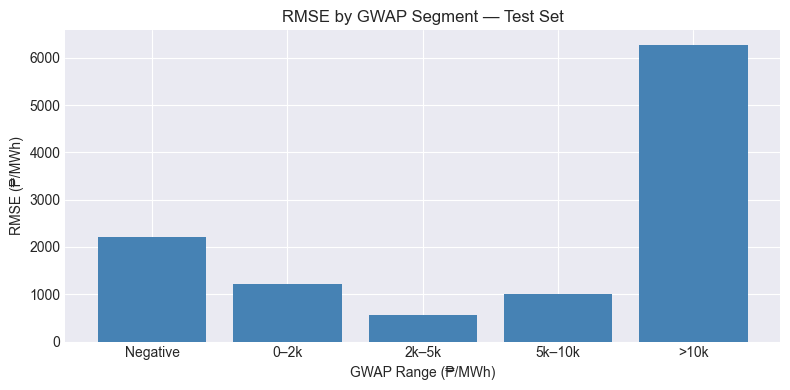

In [51]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(segment_summary["gwap_segment"].astype(str), segment_summary["rmse"], color="steelblue")
ax.set_title("RMSE by GWAP Segment — Test Set")
ax.set_xlabel("GWAP Range (₱/MWh)")
ax.set_ylabel("RMSE (₱/MWh)")
plt.tight_layout()
plt.show()

The segmented error analysis confirms what was expected:

- **Normal range (₱2,000–₱5,000)** accounts for 5,219 of 6,907 test intervals (~75.6%) and achieves an RMSE of only ₱562 — the model performs well here.
- **₱5,000–₱10,000 range** sees RMSE jump to ₱1,015, as the model begins to underpredict higher prices.
- **Negative GWAP** (459 intervals, ~6.6% of test) has an RMSE of ₱2,209. These over-generation events are abrupt and driven by non-linear strategic bidding behavior that a linear model cannot replicate.
- **Above ₱10,000** (only 18 intervals) has an RMSE of ₱6,264 — over 11× the normal-range error. These rare scarcity spikes are the hardest prediction target in the dataset.

This motivates the use of more complex models in subsequent notebooks, which may better capture the non-linear dynamics driving extreme prices.

---

## IX. Summary

In [52]:
summary = pd.DataFrame({
    "Split"     : ["Train", "Validation", "Test"],
    "RMSE"      : [train_rmse, val_rmse,  test_rmse],
    "MAE"       : [train_mae,  val_mae,   test_mae],
    "R²"        : [train_r2,   val_r2,    test_r2]
})

print("=" * 55)
print("        Linear Regression — Final Results")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)

        Linear Regression — Final Results
     Split        RMSE        MAE       R²
     Train 1212.141964 567.843838 0.813705
Validation 1066.374464 521.586008 0.832050
      Test  934.469804 459.475766 0.671426


### Key Findings

- **GWAP_Lag_1 overwhelmingly dominates all features** with a standardized coefficient of 2,175 — nearly 8× larger than the next highest (GWAP_Lag_12 at 271). This confirms that GWAP is strongly autoregressive: the single best predictor of the current price is the price from 5 minutes ago.

- **All three lag features rank in the top 3**, with GWAP_Lag_12 (1-hour lag) and GWAP_Lag_288 (24-hour lag) also carrying substantial weight. Together they account for the majority of the model's predictive power, reflecting both intraday momentum and daily seasonality in electricity prices.

- **Energy demand and supply have economically consistent signs** — demand (+164) pushes price up, supply (−116) pushes it down. Their similar magnitudes reflect the market's near-perfect demand-supply tracking observed in EDA [double-check this in EDA notebook]

- **Day-of-week features are uniformly negative** relative to Monday (the dropped reference), with Sunday (dow_6, −77) and Wednesday (dow_3, −59) showing the largest effects. This is consistent with lower commercial and industrial activity on non-Monday weekdays.

- **The model performs well in the normal price range.** For the 5,219 test intervals in the ₱2,000–₱5,000 band (~75.6% of test), RMSE is only ₱562 and MAE is ₱318.

- **The model fails significantly at price extremes.** RMSE for negative GWAP is ₱2,209 and for intervals above ₱10,000/MWh it reaches ₱6,264 — over 11× the normal-range error. These events are driven by non-linear market dynamics (strategic over-generation bidding and scarcity shocks) that a linear model fundamentally cannot capture.

- **Test R² of 0.671** means the model explains approximately 67% of GWAP variance on unseen data. The drop from validation R² (0.832) to test R² (0.671) reflects the February test period containing more extreme price events than the January validation period — making it an inherently harder target.

- **The slight performance dip from retraining on train+val** (test RMSE 934.47 vs. 934.11 on the train-only model) is negligible and expected — with no hyperparameters to tune, the additional validation data provides minimal benefit over a single month of extra training.

- These results establish the baseline. The non-linear failure modes at price extremes directly motivate the regularized models (Ridge, Elastic Net) and eventually the neural network in subsequent notebooks.